## Setup

In [3]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Pengaturan visualisasi
plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
})
sns.set_palette('Set2')

## Load & Siapkan Seluruh Data Historis 
Muat data bulanan penuh dari monthly_aggregated.csv dan tetapkan variabel target serta eksogennya (dari 03)

In [4]:
# Load data
df_m = pd.read_csv('dataset/monthly_aggregated.csv', parse_dates=['time'], index_col='time')
df_m.index.freq = 'MS'

# Definisikan kolom target dan eksogen
TARGETS = ['temperature_2m_mean', 'precipitation_sum', 'soil_moisture_0_7cm_mean', 'soil_temperature_0_7cm_mean']
EXOG = ['relative_humidity_2m_mean', 'sunshine_duration', 'precipitation_hours', 'cloud_cover_mean']

## Standardisasi Variabel Eksogen Historis
Hitung rata-rata (mean) dan standar deviasi (std) fitur eksogen dari data historis penuh untuk proses standardisasi

In [5]:
# Hitung statistik historis (1940-2025)
exog_mean = df_m[EXOG].mean()
exog_std = df_m[EXOG].std()

# Standardisasi data eksogen historis
exog_historical = (df_m[EXOG] - exog_mean) / exog_std

## Pembuatan Skenario Eksogen Masa Depan (2026–2028)
Buat matriks data eksogen masa depan selama 36 bulan ke depan (Januari 2026 - Desember 2028) berbasis Seasonal Mean dan standardisasi menggunakan statistik.

In [6]:
# Buat range index waktu masa depan
future_index = pd.date_range(start='2026-01-01', periods=36, freq='MS')

# Hitung rata-rata bulanan historis (1-12) sebagai skenario normal
exog_climatology = df_m[EXOG].groupby(df_m.index.month).mean()

# Bentuk dataframe eksogen masa depan
future_exog_data = [exog_climatology.loc[date.month] for date in future_index]
df_future_exog = pd.DataFrame(future_exog_data, index=future_index, columns=EXOG)

# Standardisasi eksogen masa depan menggunakan statistik historis
exog_future_scaled = (df_future_exog - exog_mean) / exog_std

## Latih model SARIMAX
Latih model SARIMAX untuk masing-masing target pada seluruh data historis menggunakan parameter ordo yg sudah ditetapkan. Tambahkan argumen maxiter=200 untuk menghindari convergence warning.

In [7]:
ORDERS = {
    'temperature_2m_mean':          ((1, 1, 4), (1, 1, 1, 12)),
    'precipitation_sum':             ((0, 1, 1), (0, 1, 1, 12)),
    'soil_moisture_0_7cm_mean':     ((1, 0, 2), (1, 1, 1, 12)),
    'soil_temperature_0_7cm_mean':  ((2, 1, 4), (2, 1, 0, 12)),
}

final_fits = {}

for col, (order, sorder) in ORDERS.items():
    print(f"Melatih model akhir untuk: {col}...")
    model = SARIMAX(
        df_m[col],
        exog=exog_historical,
        order=order,
        seasonal_order=sorder,
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    # Latih model secara penuh dengan maxiter ditingkatkan untuk kestabilan
    final_fits[col] = model.fit(disp=False, maxiter=200)
    print(f"-> Model {col} BERHASIL dilatih!")

Melatih model akhir untuk: temperature_2m_mean...
-> Model temperature_2m_mean BERHASIL dilatih!
Melatih model akhir untuk: precipitation_sum...
-> Model precipitation_sum BERHASIL dilatih!
Melatih model akhir untuk: soil_moisture_0_7cm_mean...
-> Model soil_moisture_0_7cm_mean BERHASIL dilatih!
Melatih model akhir untuk: soil_temperature_0_7cm_mean...
-> Model soil_temperature_0_7cm_mean BERHASIL dilatih!


## Forecasting Masa Depan & Ekstraksi Interval Kepercayaan

In [8]:
df_forecast = pd.DataFrame(index=future_index)

for col in TARGETS:
    # Peramalan 36 bulan ke depan
    forecast_obj = final_fits[col].get_forecast(steps=36, exog=exog_future_scaled)
    
    # Ambil nilai rata-rata prediksi
    df_forecast[col] = forecast_obj.predicted_mean
    
    # Ambil batas bawah & atas (confidence interval)
    conf_int = forecast_obj.conf_int(alpha=0.05)
    df_forecast[f'{col}_lower'] = conf_int.iloc[:, 0]
    df_forecast[f'{col}_upper'] = conf_int.iloc[:, 1]

print("\nProses forecasting masa depan 2026-2028 selesai!")


Proses forecasting masa depan 2026-2028 selesai!


In [12]:
# Ekspor hasil peramalan iklim ke CSV dengan label indeks 'time'
df_forecast.to_csv('dataset/forecasted_climate_2026_2028.csv', index=True, index_label='time')
print("Data prediksi masa depan berhasil disimpan ke 'dataset/forecasted_climate_2026_2028.csv'!")

PermissionError: [Errno 13] Permission denied: 'dataset/forecasted_climate_2026_2028.csv'

## Visualiasi

Grafik berhasil diekspor ke: images/report\forecast_summary_2026_2028.png


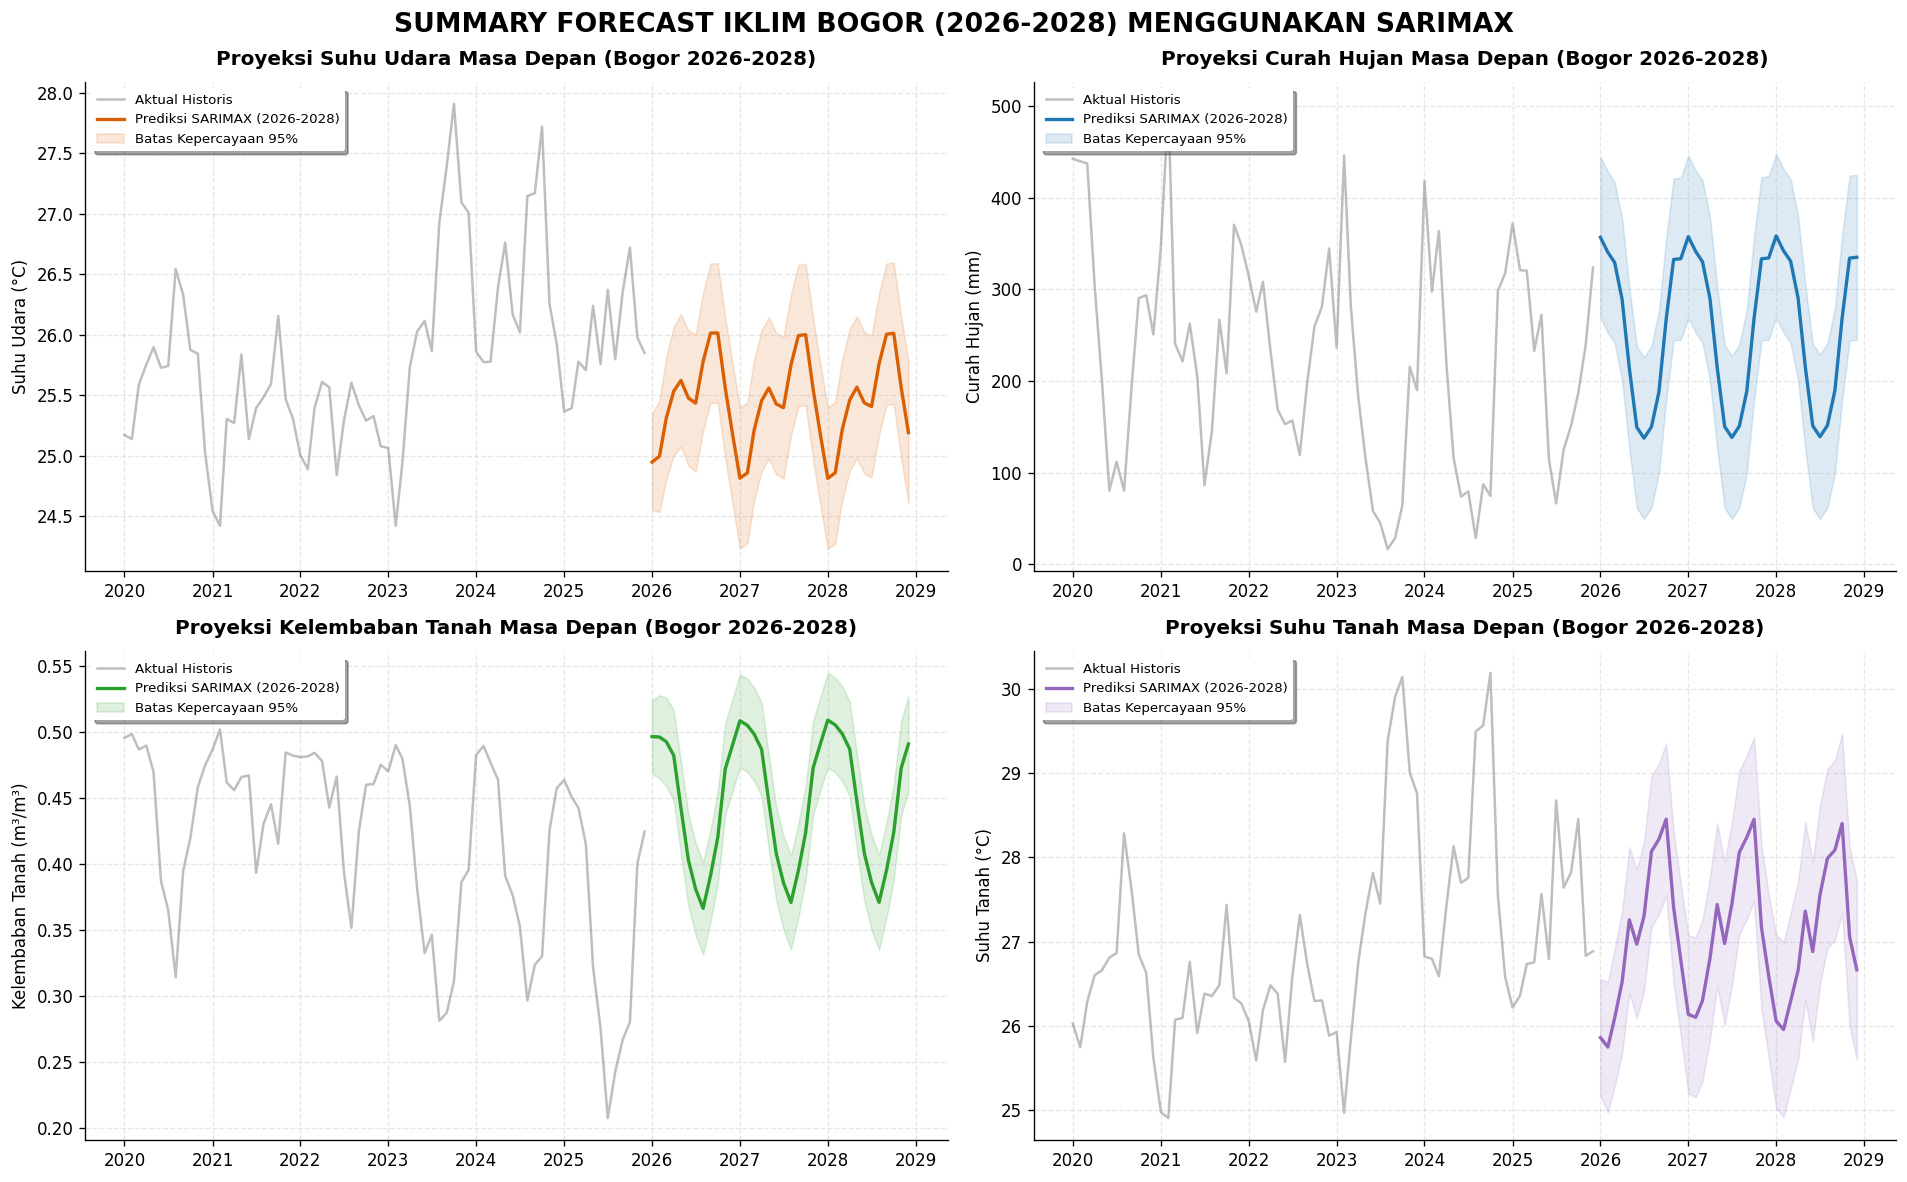

In [11]:
import os

# Konfigurasi Grid Visualisasi 2x2
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten() # Meratakan matriks axes menjadi list 1D agar mudah di-iterasi

# Definisikan gaya visual unik untuk masing-masing target
visual_styles = {
    'temperature_2m_mean': {
        'title': 'Proyeksi Suhu Udara Masa Depan (Bogor 2026-2028)',
        'ylabel': 'Suhu Udara (°C)',
        'color': '#d95f02', # Oranye gelap untuk suhu
        'hist_start_year': '2020'
    },
    'precipitation_sum': {
        'title': 'Proyeksi Curah Hujan Masa Depan (Bogor 2026-2028)',
        'ylabel': 'Curah Hujan (mm)',
        'color': '#1f78b4', # Biru untuk air/curah hujan
        'hist_start_year': '2020'
    },
    'soil_moisture_0_7cm_mean': {
        'title': 'Proyeksi Kelembaban Tanah Masa Depan (Bogor 2026-2028)',
        'ylabel': 'Kelembaban Tanah (m³/m³)',
        'color': '#2ca02c', # Hijau untuk tanah/kelembaban
        'hist_start_year': '2020'
    },
    'soil_temperature_0_7cm_mean': {
        'title': 'Proyeksi Suhu Tanah Masa Depan (Bogor 2026-2028)',
        'ylabel': 'Suhu Tanah (°C)',
        'color': '#9467bd', # Ungu untuk suhu tanah
        'hist_start_year': '2020'
    }
}

for idx, col in enumerate(TARGETS):
    ax = axes[idx]
    style = visual_styles[col]
    
    # Plot Data Aktual Historis (mulai tahun 2020 agar pola masa depan terlihat jelas)
    ax.plot(
        df_m[col].loc[style['hist_start_year']:], 
        label='Aktual Historis', 
        color='#7f7f7f', 
        alpha=0.5, 
        linewidth=1.5
    )
    
    # Plot Garis Hasil Prediksi SARIMAX (2026-2028)
    ax.plot(
        df_forecast[col], 
        label='Prediksi SARIMAX (2026-2028)', 
        color=style['color'], 
        linewidth=2
    )
    
    # Plot Batas Kepercayaan 95% (fill_between)
    ax.fill_between(
        df_forecast.index, 
        df_forecast[f'{col}_lower'], 
        df_forecast[f'{col}_upper'], 
        color=style['color'], 
        alpha=0.15, 
        label='Batas Kepercayaan 95%'
    )
    
    # Konfigurasi Teks & Desain di Sub-plot
    ax.set_title(style['title'], fontsize=12, fontweight='bold', pad=10)
    ax.set_ylabel(style['ylabel'], fontsize=10)
    ax.legend(loc='upper left', fontsize=8, frameon=True, facecolor='white', edgecolor='none', shadow=True)
    ax.grid(True, linestyle='--', alpha=0.3)

plt.suptitle('SUMMARY FORECAST IKLIM BOGOR (2026-2028) MENGGUNAKAN SARIMAX', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()

# Ekspor Grafik
output_dir = 'images/report'
os.makedirs(output_dir, exist_ok=True) # Membuat folder images/report jika belum ada

output_path = os.path.join(output_dir, 'forecast_summary_2026_2028.png')

# Simpan grafik sebagai file gambar dengan resolusi cetak tinggi (300 DPI)
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"Grafik berhasil diekspor ke: {output_path}")

# Tampilkan grafik di sel notebook
plt.show()